## AI vs Human marketing content: consumer perception analysis

This notebook presents descriptive statistics and visual analysis of the results from a perception survey conducted as part of the Retail and Marketing Analytics module. The study investigates whether generative AI can replicate or exceed the effectiveness of human created marketing content in shaping consumer perception. To work on this, the analysis below compares those AI generated and human created images across key dimensions such as perceived quality, realism, visual appeal, and marketing effectiveness. It further explores whether consumers are able to distinguish between those content, and whether these perceptions vary across demographic characteristics and levels of familiarity with AI tools. By combining perceptual ratings with behavioural preference measures, the study aims to provide a comprehensive assessment of the role of generative AI in visual marketing.

**Main research question:** To what extent can generative AI create visual marketing content that matches or exceeds human created content in terms of perceived quality, realism, aesthetics, and marketing effectiveness?

**Sub questions:**  
1. How do perceptions of quality, realism, and aesthetics vary across the evaluated images?  
2. How do perceptions of realism for AI generated and human created images vary across age groups?  
3. To what extent are consumers able to distinguish between AI generated and human created images?  
4. How do AI generated and human created images differ in driving consumer preferences across key marketing outcomes such as effectiveness, clarity, interest, and attraction?  
5. Which content performs better on social media in capturing respondents’ attention: AI or human images?  
6. How does familiarity with AI influence the perception of AI generated versus human created images?  


### 1. Data preparation and cleaning:

The first section outlines the process undertaken to prepare the survey dataset for analysis. The raw data, collected in Excel format, was initially cleaned by removing irrelevant metadata columns such as timestamps and identifiers, as these do not contribute to the analytical objectives of the study. Column names and text responses were subsequently standardised to ensure consistency and to minimise issues arising from formatting inconsistencies in the original dataset.

To enable quantitative analysis, likert scale responses were converted from textual formats into numerical values, as this transformation is essential for facilitating statistical comparison across evaluation dimensions and image types. In addition to this, relevant labels were defined to classify each image as either AI generated or human created, providing a clear and consistent basis for comparative analysis throughout the study. Furthermore, given the semi structured nature of the survey output, pattern matching techniques were employed to systematically identify and map survey questions to their corresponding image numbers and evaluation dimensions. This approach ensured accurate organisation of the data despite minor variations in column naming, thereby improving both the reliability and reproducibility of the data preparation process.

The dataset was then reshaped into a long format, where each row represents a single evaluation score associated with a specific image and assessment criterion. Such a structure enhances analytical flexibility by enabling efficient grouping, aggregation, and visualisation of results across multiple dimensions, including image type and demographic characteristics. Overall, the steps below ensure that the dataset is both analytically robust and appropriately structured for subsequent descriptive and comparative analysis.

In [75]:
#importing libraries: 
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#setting a clean and readable visual style for plots: 
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [76]:
#file load:
file_path = "Study on how people perceive marketing images(1-83).xlsx"

df_raw = pd.read_excel(file_path)
print(df_raw.shape)
df_raw.head()

(83, 106)


,ID,Start time,Completion time,Email,Name,Last modified time,The image looks realistic.,The objects in the image look high‑quality.,The image is visually attractive.,The visual elements look professionally produced.,The objects in the image appear natural rather than artificial.,The colour scheme used in this image is pleasing.,The visual details in the image are clear and well executed.,The textures in the image resemble those found in real life.,This image would capture my attention on social media.,The image looks realistic.2,The objects in the image look high‑quality.2,The image is visually attractive.2,The visual elements look professionally produced.2,The objects in the image appear natural rather than artificial.2,The colour scheme used in this image is pleasing.2,The visual details in the image are clear and well executed.2,The textures in the image resemble those found in real life. 2,This image would capture my attention on social media.2,The image looks realistic.3,The objects in the image look high‑quality.3,The image is visually attractive.3,The visual elements look professionally produced.3,The objects in the image appear natural rather than artificial.3,The colour scheme used in this image is pleasing.3,The visual details in the image are clear and well executed.3,The texture in the image resemble those found in real life.,This image would capture my attention on social media.3,The image looks realistic.4,The objects in the image look high‑quality.4,The image is visually attractive.4,The visual elements look professionally produced.4,The objects in the image appear natural rather than artificial.4,The colour scheme used in this image is pleasing.4,The visual details in the image are clear and well executed.4,The texture in the image resemble those found in real life. 2,This image would capture my attention on social media.4,The image looks realistic.5,The objects in the image look high‑quality.5,The image is visually attractive.5,The visual elements look professionally produced.5,The objects in the image appear natural rather than artificial.5,The colour scheme used in this image is pleasing.5,The visual details in the image are clear and well executed.5,The texture in the image resemble those found in real life. 3,This image would capture my attention on social media.5,The image looks realistic.6,The objects in the image look high‑quality.6,The image is visually attractive.6,The visual elements look professionally produced.6,The objects in the image appear natural rather than artificial.6,The colour scheme used in this image is pleasing.6,The visual details in the image are clear and well executed.6,The texture in the image resemble those found in real life. 4,This image would capture my attention on social media.6,The image looks realistic.7,The objects in the image look high‑quality.7,The image is visually attractive.7,The visual elements look professionally produced.7,The objects in the image appear natural rather than artificial.7,The colour scheme used in this image is pleasing.7,The visual details in the image are clear and well executed.7,The texture in the image resemble those found in real life. 5,This image would capture my attention on social media.7,The image looks realistic.8,The objects in the image look high‑quality.8,The image is visually attractive.8,The visual elements look professionally produced.8,The objects in the image appear natural rather than artificial.8,The colour scheme used in this image is pleasing.8,The visual details in the image are clear and well executed.8,The texture in the image resemble those found in real life. 6,This image would capture my attention on social media.8,The image looks realistic.9,The objects in the image look high‑quality.9,The image is visually attractive.9,The visual elements look professionally produced.9,The objects in the image appear natural rather than artificial.9,The colour scheme used in this image is pleasing.9,The visual details in the image ar

In [77]:
#basic cleaning of the excel file and creating a working copy so original data remains unchanged: 
df = df_raw.copy() 

#remove metadata columns that are not needed for analysis: 
meta_cols = ["ID", "Start time", "Completion time", "Email", "Name", "Last modified time"]
df = df.drop(columns=[c for c in meta_cols if c in df.columns], errors="ignore")

#clean column names for consistency: 
df.columns = [str(c).strip() for c in df.columns]

print("Rows, columns:", df.shape)
print(df.columns.tolist()[:20])

Rows, columns: (83, 100)
['The image looks realistic.', 'The objects in the image look high‑quality.', 'The image is visually attractive.', 'The visual elements look professionally produced.', 'The objects in the image appear natural rather than artificial.', 'The colour scheme used in this image is pleasing.', 'The visual details in the      image are clear and well executed.', 'The textures in the image resemble those found in real life.', 'This image would capture my      attention on social media.', 'The image looks realistic.2', 'The objects in the image look high‑quality.2', 'The image is visually attractive.2', 'The visual elements look professionally produced.2', 'The objects in the image appear natural rather than artificial.2', 'The colour scheme used in this image is pleasing.2', 'The visual details in the      image are clear and well executed.2', 'The textures in the image resemble those found in real life.\xa02', 'This image would capture my      attention on social media

In [78]:
#defining labels for each image number to its source type classifying as either ai or human for comparative analysis:
image_label_map = {1: "Human", 2: "AI", 3: "AI", 4: "Human", 5: "Human", 6: "Human", 7: "Human", 8: "AI", 9: "AI", 10: "AI"}

#mapping internal item names to clean readable labels:
item_label_map = {"realistic": "Realistic", "high_quality": "High quality", "visually_attractive": "Visually attractive",
                  "professionally_produced": "Professionally produced", "natural_not_artificial": "Natural appearance", 
                  "colour_scheme": "Pleasant colour scheme", "clear_details": "Clear visual details", "real_life_texture": "Real life textures",
                  "captures_attention": "Captures attention"}



In [40]:
#listing the demographic variables to analyse differences across groups: 
demographic_cols = ["Age", "Gender", "Education Level", "Familiarity with AI images tools", "How often do you use social media?"]

#checking which of these columns actually exist in the dataset (in case of naming differences): 
existing_demographic_cols = [c for c in demographic_cols if c in df.columns]

print("Demographic columns found:", existing_demographic_cols)

Demographic columns found: ['Age', 'Gender', 'Education Level', 'Familiarity with AI images tools', 'How often do you use social media?']


In [41]:
#helper functions to clean text and convert likert responses into numbers:
def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("\xa0", " ").strip()
    x = re.sub(r"\s+", " ", x)
    return x

#converting responses like 1 (strongly disagree) into just the number 1: 
def extract_likert_score(x):
    if pd.isna(x):
        return np.nan
    x = clean_text(x)
    match = re.search(r"^(\d+)", x)
    if match:
        return int(match.group(1))
    return np.nan

#applying text cleaning to all object (text) columns in the dataset: 
for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].apply(clean_text)

In [42]:
#mapping internal variable names from the survey dataset to clean, readable labels used in visualisations and analysis ensuring consistency and interpretability of results: 
item_patterns = {"realistic": r"realistic", "high_quality": r"high.?quality", "visually_attractive": r"visually attractive",
                 "professionally_produced": r"professionally produced", "natural_not_artificial": r"natural rather than artificial",
                 "colour_scheme": r"colour scheme", "clear_details": r"clear.*executed", "real_life_texture": r"texture",
                 "captures_attention": r"capture.*attention"}

#mapping te group labels to more descriptive names for reporting purposes: 
group_label_map = {"Group A": "Generative AI", "Group B": "Human Content"} 

#adding the function to extract the image number from the column name:
def get_image_number(colname):
    m = re.search(r"\.(\d+)$", colname)
    if m:
        return int(m.group(1))
    return 1

#looping through all columns and match them to the correct image and question: 
mapping = []
for col in df.columns:
    for item_name, pattern in item_patterns.items():
        if re.search(pattern, col, flags=re.IGNORECASE):
            mapping.append({
                "column": col,
                "image_number": get_image_number(col),
                "item": item_name
            })

#creating a structured dataframe showing which column belongs to which image and question: 
mapping_df = pd.DataFrame(mapping).sort_values(["image_number", "item"])
mapping_df.head(20)

,column,image_number,item
8,This image would capture my attention on ...,1,captures_attention
6,The visual details in the image are clear...,1,clear_details
5,The colour scheme used in this image is pleasing.,1,colour_scheme
1,The objects in the image look high‑quality.,1,high_quality
4,The objects in the image appear natural rather...,1,natural_not_artificial
3,The visual elements look professionally produced.,1,professionally_produced
7,The textures in the image resemble those found...,1,real_life_texture
16,The textures in the image resemble those found...,1,real_life_texture
25,The texture in the image resemble those found ...,1,real_life_texture
34,The texture in the image resemble those found ...,1,real_life_texture


In [43]:
#converting all likert responses into numeric values so they can be analysed: 
df_num = df.copy()

#list of all rating columns identified earlier, applying the likert conversion function, and ensuring familiarity with AI tools is stored as a numeric variable:
rating_cols = mapping_df["column"].tolist()
for c in rating_cols:
    df_num[c] = df_num[c].apply(extract_likert_score)
if "Familiarity with AI images tools" in df_num.columns:
    df_num["Familiarity with AI images tools"] = pd.to_numeric(
        df_num["Familiarity with AI images tools"], errors="coerce"
    )

df_num[rating_cols].head()

,This image would capture my attention on social media.,The visual details in the image are clear and well executed.,The colour scheme used in this image is pleasing.,The objects in the image look high‑quality.,The objects in the image appear natural rather than artificial.,The visual elements look professionally produced.,The textures in the image resemble those found in real life.,The textures in the image resemble those found in real life. 2,The texture in the image resemble those found in real life.,The texture in the image resemble those found in real life. 2,The texture in the image resemble those found in real life. 3,The texture in the image resemble those found in real life. 4,The texture in the image resemble those found in real life. 5,The texture in the image resemble those found in real life. 6,The texture in the image resemble those found in real life. 7,The texture in the image resemble those found in real life. 8,The image looks realistic.,The image is visually attractive.,This image would capture my attention on social media.2,The visual details in the image are clear and well executed.2,The colour scheme used in this image is pleasing.2,The objects in the image look high‑quality.2,The objects in the image appear natural rather than artificial.2,The visual elements look professionally produced.2,The image looks realistic.2,The image is visually attractive.2,This image would capture my attention on social media.3,The visual details in the image are clear and well executed.3,The colour scheme used in this image is pleasing.3,The objects in the image look high‑quality.3,The objects in the image appear natural rather than artificial.3,The visual elements look professionally produced.3,The image looks realistic.3,The image is visually attractive.3,This image would capture my attention on social media.4,The visual details in the image are clear and well executed.4,The colour scheme used in this image is pleasing.4,The objects in the image look high‑quality.4,The objects in the image appear natural rather than artificial.4,The visual elements look professionally produced.4,The image looks realistic.4,The image is visually attractive.4,This image would capture my attention on social media.5,The visual details in the image are clear and well executed.5,The colour scheme used in this image is pleasing.5,The objects in the image look high‑quality.5,The objects in the image appear natural rather than artificial.5,The visual elements look professionally produced.5,The image looks realistic.5,The image is visually attractive.5,This image would capture my attention on social media.6,The visual details in the image are clear and well executed.6,The colour scheme used in this image is pleasing.6,The objects in the image look high‑quality.6,The objects in the image appear natural rather than artificial.6,The visual elements look professionally produced.6,The image looks realistic.6,The image is visually attractive.6,This image would capture my attention on social media.7,The visual details in the image are clear and well executed.7,The colour scheme used in this image is pleasing.7,The objects in the image look high‑quality.7,The objects in the image appear natural rather than artificial.7,The visual elements look professionally produced.7,The image looks realistic.7,The image is visually attractive.7,This image would capture my attention on social media.8,The visual details in the image are clear and well executed.8,The colour scheme used in this image is pleasing.8,The objects in the image look high‑quality.8,The objects in the image appear natural rather than artificial.8,The visual elements look professionally produced.8,The image looks realistic.8,The image is visually attractive.8,This image would capture my attention on social media.9,The visual details in the image are clear and well executed.9,The colour scheme used in this image is pleasing.9,The objects in the image look high‑quality.9,The objects in the image appear

In [44]:
#reshaping the dataset into a long format so each row represents one rating for a specific image and evaluation dimension: 
long_rows = []

#looping through each column to restructure the data so that each row represents a single rating with its corresponding image, dimension, and demographics:
for _, row in mapping_df.iterrows():
    col = row["column"]
    img = row["image_number"]
    item = row["item"]
    
    temp = df_num[[col] + existing_demographic_cols].copy()
    temp = temp.rename(columns={col: "score"})
    temp["image_number"] = img
    temp["item"] = item
    long_rows.append(temp)

#combining all rows into one dataframe: 
ratings_long = pd.concat(long_rows, ignore_index=True)

#clean any missing scores: 
ratings_long = ratings_long.dropna(subset=["score"])

#making interpretable labels for use in analysis and visualisations to avoid working with coded variable names later on: 
ratings_long["image_label"] = ratings_long["image_number"].map(image_label_map)
ratings_long["item_label"] = ratings_long["item"].map(item_label_map)

#classifying each image as AI or human made: 
ratings_long["image_group"] = ratings_long["image_number"].map(image_label_map)

print(ratings_long.shape)
ratings_long.head()

(7470, 11)


,score,Age,Gender,Education Level,Familiarity with AI images tools,How often do you use social media?,image_number,item,image_label,item_label,image_group
0,1,45 - 54,Female,Undergraduate (Bachelor's),3,Daily,1,captures_attention,Human,Captures attention,Human
1,1,18 - 24,Female,Postgraduate (Master's / Doctorate),6,Multiple times per day,1,captures_attention,Human,Captures attention,Human
2,3,25 - 34,Female,Undergraduate (Bachelor's),4,Daily,1,captures_attention,Human,Captures attention,Human
3,7,25 - 34,Female,Postgraduate (Master's / Doctorate),7,Multiple times per day,1,captures_attention,Human,Captures attention,Human
4,7,45 - 54,Male,Undergraduate (Bachelor's),5,A few times a month,1,captures_attention,Human,Captures attention,Human


### 2. Descriptive statistics and data overview: 

Section 2 presents summary statistics to provide an initial overview of how respondents evaluated the marketing images across all dimensions. The analysis focuses on overall response patterns, as well as variations across evaluation criteria and individual images.

Across all observations (n = 7,470), the mean rating is 5.04, indicating that, on average, images were evaluated positively on the 1-7 likert scale. The median score of 5 and the interquartile range (4–6) further suggest that most responses are concentrated in the upper range of the scale, reflecting generally favourable perceptions. However, the relatively high standard deviation (1.76) indicates notable variability in responses, suggesting differences in how participants perceived certain images or dimensions.

When examining results by evaluation dimension, clear differences emerge in terms of attributes like professional production (mean = 5.33), clear details (mean = 5.30), and high quality (mean = 5.27) receive the highest ratings, indicating that both AI and human generated images perform strongly in terms of visual execution. In contrast, realism (mean = 4.43) and natural appearance (mean = 4.51) receive comparatively lower scores, suggesting that respondents were more critical of how realistic or natural the images appeared, highlighting realism as a key differentiating factor in perception.

At the image level, variation in performance is also observed, these include image 6 (mean = 5.38) and image 4 (mean = 5.35) achieve the highest average ratings, indicating strong overall effectiveness. In contrast, image 1 (mean = 4.66) and image 8 (mean = 4.68) receive lower scores, suggesting comparatively weaker performance. These differences reinforce the presence of variation not only across dimensions but also across individual visual stimuli.

Besides this, to support the interpretation of the descriptive results, a brief overview of the sample characteristics was conducted using key demographic variables, including age, gender, education level, familiarity with AI tools, and social media usage. In this part, visualisations and summary metrics were used to understand the composition of respondents and assess how representative the sample is for this study. Examining these characteristics is important, as exposure to digital technologies and familiarity with AI may influence how individuals perceive marketing images. In particular, higher levels of AI familiarity and frequent social media usage suggest that respondents are likely accustomed to digital and potentially AI generated content, which is relevant given the focus of this research.

Overall, this section provides important context for interpreting the results and helps identify any potential biases in the sample. A summary of key demographic insights is presented alongside the visualisations.

In [45]:
#calculating overall summary statistics and breaking them down by evaluation dimension and image:
overall_desc = ratings_long["score"].describe()

print("Overall descriptive statistics")
display(overall_desc)

Overall descriptive statistics


count    7470.000000
mean        5.036011
std         1.760127
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max         7.000000
Name: score, dtype: float64

In [46]:
#summary statistics for each evaluation dimension:
item_desc = ratings_long.groupby("item")["score"].agg(["count", "mean", "std", "median", "min", "max"]).round(2)

print("Descriptive statistics across evaluation dimension")
display(item_desc)

Descriptive statistics across evaluation dimension


,count,mean,std,median,min,max
item,,,,,,
captures_attention,830,4.92,1.89,5.0,1,7
clear_details,830,5.30,1.60,6.0,1,7
colour_scheme,830,5.23,1.70,6.0,1,7
high_quality,830,5.27,1.60,6.0,1,7
natural_not_artificial,830,4.51,1.86,5.0,1,7
professionally_produced,830,5.33,1.60,6.0,1,7
real_life_texture,830,5.13,1.60,5.0,1,7
realistic,830,4.43,1.97,5.0,1,7
visually_attractive,830,5.19,1.71,6.0,1,7


In [47]:
#summary statistics for each image: 
image_desc = ratings_long.groupby("image_number")["score"].agg(["count", "mean", "std", "median", "min", "max"]).round(2)

print("Descriptive statistics at the image level")
display(image_desc)

Descriptive statistics at the image level


,count,mean,std,median,min,max
image_number,,,,,,
1,1494,4.66,1.80,5.0,1,7
2,664,5.30,1.58,6.0,1,7
3,664,5.17,1.91,6.0,1,7
4,664,5.35,1.60,6.0,1,7
5,664,5.21,1.73,6.0,1,7
6,664,5.38,1.58,6.0,1,7
7,664,4.77,1.85,5.0,1,7
8,664,4.68,1.93,5.0,1,7
9,664,5.27,1.64,6.0,1,7


In [48]:
#dataset overview before the analysis:

#determining the total number of respondents for the survey: 
num_responses = df.shape[0]
print("Number of responses:", num_responses)

#checking the proportion of AI vs human images used in the survey: 
image_type_map = {1:"Human",2:"AI",3:"AI",4:"Human",5:"Human",6:"Human",7:"Human",8:"AI",9:"AI",10:"AI"}
image_df = pd.DataFrame(list(image_type_map.items()), columns=["image_number", "image_group"])

image_counts = (image_df["image_group"].value_counts(normalize=True) * 100).round(1)
print("AI images (%):", image_counts["AI"])
print("Human images (%):", image_counts["Human"])

#confirming dataset structure aligns with survey design: 
print("Total images:", ratings_long["image_number"].nunique())
print("Evaluation dimensions:", ratings_long["item"].nunique())
print("Total ratings collected:", ratings_long.shape[0])

Number of responses: 83
AI images (%): 50.0
Human images (%): 50.0
Total images: 10
Evaluation dimensions: 9
Total ratings collected: 7470


In [49]:
#analysing the demographics of the survey: 
age_order = ["Under 18", "18–24", "25–34", "35–44", "45–54", "55+"]

#cleaning and standardising age labels for consistency: 
df["Age"] = (
    df["Age"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*-\s*", "-", regex=True)
    .str.replace("–", "-"))

df["Age"] = df["Age"].replace({
    "18-24": "18–24",
    "25-34": "25–34",
    "35-44": "35–44",
    "45-54": "45–54"})

#checking the number of respondents per age group: 
age_counts = df["Age"].value_counts().reindex(age_order).fillna(0)
age_counts.index.name = None
print("Age (number of respondents per group):")
print(age_counts)

#checking the age distribution in percentage: 
age_percent = (df["Age"].value_counts(normalize=True) * 100).round(1)
age_percent = age_percent.reindex(age_order).fillna(0)
age_percent.index.name = None
print("\nAge distribution (%):")
print(age_percent)

#and now checking the gender distribution in percentage: 
gender_percent = (df["Gender"].value_counts(normalize=True) * 100).round(1)
gender_percent.index.name = None
print("\nGender distribution (%):")
print(gender_percent)

Age (number of respondents per group):
Under 18    15
18–24       30
25–34       22
35–44        6
45–54        6
55+          4
Name: count, dtype: int64

Age distribution (%):
Under 18    18.1
18–24       36.1
25–34       26.5
35–44        7.2
45–54        7.2
55+          4.8
Name: proportion, dtype: float64

Gender distribution (%):
Female               49.4
Male                 47.0
Prefer not to say     3.6
Name: proportion, dtype: float64


In [50]:
#looking at the education profile of the respondents:

#calculating the percentage distribution of education levels to understand sample background: 
education_percent = (df["Education Level"].value_counts(normalize=True) * 100).round(1)
education_percent.index.name = None  # remove duplicate label for cleaner output

print("Education profile of respondents (%):")
print(education_percent)

#estimating how many respondents have university level education which inlcudes undergrad and postgrad: 
university_percent = df["Education Level"].isin(["Undergraduate (Bachelor's)", "Postgraduate (Master's / Doctorate)"]).mean() * 100
print("\nProportion of respondents with university education (%):", round(university_percent, 1))

Education profile of respondents (%):
Undergraduate (Bachelor's)             41.0
Secondary / High school                30.1
Postgraduate (Master's / Doctorate)    24.1
Diploma                                 4.8
Name: proportion, dtype: float64

Proportion of respondents with university education (%): 65.1


In [51]:
#now checking the respondents' familiarity with ai: 

#calculating how familiar respondents are with ai tools based on the survey scale: 
ai_familiarity_percent = (df["Familiarity with AI images tools"].value_counts(normalize=True) * 100).round(1)
ai_familiarity_percent.index.name = None  

print("\nFamiliarity with AI tools among respondents (%):")
print(ai_familiarity_percent)

#estimating proportion of respondents with relatively high familiarity which includes scores 4 to 7 on the scale: 
high_ai_familiarity = df["Familiarity with AI images tools"].isin([4,5,6,7]).mean() * 100
print("\nProportion of respondents with high familiarity with AI tools (%):", round(high_ai_familiarity, 1))


Familiarity with AI tools among respondents (%):
5    30.1
4    24.1
6    20.5
7    15.7
3     6.0
2     3.6
Name: proportion, dtype: float64

Proportion of respondents with high familiarity with AI tools (%): 90.4


In [52]:
#checking social media usage patterns:

#calculating how frequently respondents use social media to understand engagement levels: 
social_media_percent = (df["How often do you use social media?"].value_counts(normalize=True) * 100).round(1)
social_media_percent.index.name = None  

print("\nSocial media usage among respondents (%):")
print(social_media_percent)

#estimating the proportion of highly active users (daily or multiple times per day): 
frequent_users_percent = df["How often do you use social media?"].isin(["Daily", "Multiple times per day"]).mean() * 100
print("\nProportion of frequent social media users (%):", round(frequent_users_percent, 1))


Social media usage among respondents (%):
Multiple times per day    48.2
Daily                     47.0
Rarely                     2.4
A few times a month        1.2
A few times a week         1.2
Name: proportion, dtype: float64

Proportion of frequent social media users (%): 95.2


In [53]:
print("\nData overview:")
print("Proportion of respondents with university education (%):", round(university_percent, 1))
print("Proportion of respondents with high familiarity with AI tools (%):", round(high_ai_familiarity, 1))
print("Proportion of respondents who use social media frequently (%):", round(frequent_users_percent, 1))


Data overview:
Proportion of respondents with university education (%): 65.1
Proportion of respondents with high familiarity with AI tools (%): 90.4
Proportion of respondents who use social media frequently (%): 95.2


In [54]:
#visualisation for gender distribution: 

#putting the gender data: 
df_gender = pd.DataFrame({"gender": ["Female", "Male", "Undisclosed"], "percentage": [49.4, 47.0, 3.6]})

#creating a bar chart to visually summarise gender composition of respondents: 
fig = px.bar(df_gender, x="gender", y="percentage", title="Gender distribution of respondents", text="percentage", color="gender", 
             color_discrete_map={"Female": "#8b1e1e", "Male": "#1f3b73", "Undisclosed": "#2e8b57"})

#showing the percentage labels clearly above each bar for readability: 
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

#applying a consistent style for all visuals: 
fig.update_layout(template="simple_white", width=900, height=600, title_font_size=22,
                  xaxis=dict(title="Gender", showgrid=True, gridcolor="lightgrey"),
                  yaxis=dict(title="Percentage (%)", showgrid=True, gridcolor="lightgrey", dtick=10),
                  showlegend=False)

fig.show()

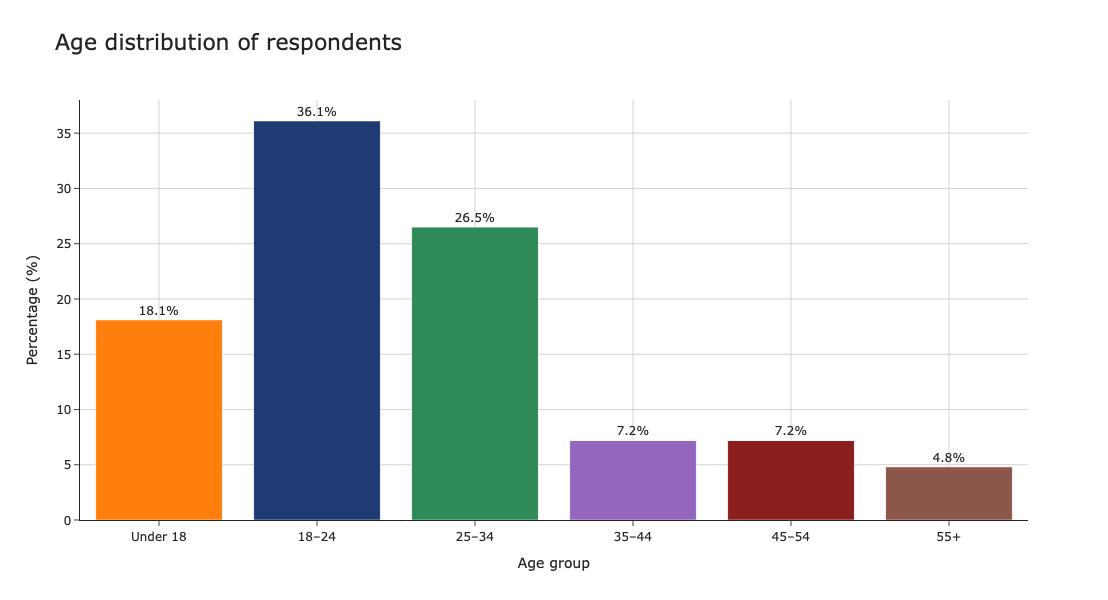

In [55]:
#visualisation for age distribution: 

#first ensuring that the age groups follow logical order for better interpretation:
order = ["Under 18", "18–24", "25–34", "35–44", "45–54", "55+"]
age_percent = age_percent.reindex(order)

#creating bar chart to visualise age distribution of respondents:
fig = px.bar(x=age_percent.index, y=age_percent.values, title="Age distribution of respondents",
             text=age_percent.values, color=age_percent.index,
             color_discrete_sequence=["#ff7f0e", "#1f3b73", "#2e8b57", "#9467bd", "#8b1e1e", "#8c564b"])

#adding percentage labels above bars for clarity:
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

#applying a consistent style for all visuals:
fig.update_layout(template="simple_white", width=900, height=600, title_font_size=22,
                  xaxis=dict(title="Age group", showgrid=True, gridcolor="lightgrey"),
                  yaxis=dict(title="Percentage (%)", showgrid=True, gridcolor="lightgrey", dtick=5),
                  showlegend=False)

fig.show()

### 3. Comparative analysis of AI vs Human image perception: 

This section presents a comparative analysis of how AI generated and human created marketing images are are evaluated by respondents. Building on the descriptive overview in the previous section, the analysis now shifts to addressing the research questions. In particular, it examines whether AI generated content can match or exceed human created images across key perceptual dimensions, whether respondents appear able to distinguish between the two, and whether these differences extend into more applied marketing outcomes such as effectiveness, attention, and behavioural preference.

The comparative analysis is organised across multiple subsections, each addressing a different aspect of the broader research problem. The first focuses on overall perceptual performance across quality, realism, and aesthetics. The following sections then explore how realism varies across age groups, whether perceived realism can be used as a proxy for distinguishing AI from human created content, whether perceptions translate into behavioural preferences, how effectively different images capture attention, and finally whether familiarity with AI tools shapes evaluation patterns. Together, these analyses provide a more complete view of whether generative AI can truly replicate the role of human created marketing visuals, or whether important perceptual and behavioural gaps remain.

#### 3.1 Overall performance across evaluation dimensions: 

This subsection establishes a baseline view of how images perform across key perceptual dimensions before moving into more specific comparisons. By examining mean scores for quality, realism, and aesthetics, it identifies which attributes drive performance and where limitations are most apparent, particularly for AI generated content. Following the analysis, these insights help understand whether any observed differences are primarily linked to realism, visual appeal, or technical execution, and provide direction for the more detailed analyses that follow.

In [56]:
#filtering key evaluation dimensions using labels from dataset:
filtered = ratings_long[ratings_long["item_label"].isin(["High quality", "Realistic", "Visually attractive"])]

#renaming these labels to simpler terms for cleaner legend:
filtered = filtered.rename(columns={"item_label": "dimension"})
filtered["dimension"] = filtered["dimension"].replace({"High quality": "Quality", "Realistic": "Realism", "Visually attractive": "Aesthetics"})

#aggregating mean scores across images and evaluation dimensions to understand overall perception patterns:
line_data = filtered.groupby(["image_number", "dimension"])["score"].mean().reset_index()

#creating line chart to compare how each evaluation dimension varies across images:
fig = px.line(line_data, x="image_number", y="score", color="dimension", markers=True,
              title="Perceived performance across AI vs Human images (all age groups under 18 to 55+)",
              color_discrete_map={"Quality": "#1f3b73", "Realism": "#8b1e1e", "Aesthetics": "#2e8b57"})

#applying consistent layout styling:
fig.update_layout(template="simple_white", width=1000, height=600, title_font_size=19,
                  xaxis=dict(title="Image number", dtick=1, showgrid=True, gridcolor="lightgrey"),
                  yaxis=dict(title="Mean score", range=[1, 7], dtick=0.5, showgrid=True, gridcolor="lightgrey"))

#adding value labels:
fig.update_traces(text=line_data["score"].round(2), textposition="top center")

#displaying final chart:
fig.show()

#### 3.2 Variation in realism perception across age groups: 

To build on the overall perceptual comparison, this subsection focuses specifically on realism and examines how it varies across age groups. Realism was selected as the focal dimension because it was one of the weaker performing attributes in the descriptive analysis and because it is particularly relevant to the question of whether consumers can meaningfully distinguish between AI and human created content. 

The rationale for this analysis is that perceptions of realism may not be uniform across respondents. Different age groups are likely to differ in their familiarity with digital imagery, their exposure to online content, and their sensitivity to artificial looking visuals. As a result, realism provides a useful way to explore whether demographic characteristics shape how AI marketing images are interpreted. Rather than treating all respondents as a single group, this section investigates whether the gap between AI and human created content changes across stages of the age distribution. Furthermore, the analysis in this section adds nuance to the main research question as the effectiveness of AI generated content may depend not only on the image itself, but also on the type of audience viewing it. Finally, by focusing on realism across age groups, the analysis done therefore helps assess whether AI generated visuals are more acceptable to some audiences than others.

In [57]:
#filtering only realism dimension to focus on differences in perceived realism:
realism_data = filtered[filtered["dimension"] == "Realism"].copy()

#cleaning and standardising age labels to ensure consistency across responses:
realism_data["Age"] = realism_data["Age"].astype(str).str.strip().str.replace(r"\s*-\s*", "-", regex=True).str.replace("–", "-")

#aligning all age labels to a consistent format for grouping:
realism_data["Age"] = realism_data["Age"].replace({"18-24": "18–24", "25-34": "25–34", "35-44": "35–44", "45-54": "45–54", "55+": "55+", "Under 18": "Under 18"})

#defining the age order to improve readability in visual output:
age_order = ["Under 18", "18–24", "25–34", "35–44", "45–54", "55+"]

#converting age into ordered categorical variable to preserve correct plotting order:
realism_data["Age"] = pd.Categorical(realism_data["Age"], categories=age_order, ordered=True)

#calculating mean realism scores by age group and image type to compare perceptions:
demo_summary = realism_data.dropna(subset=["Age"]).groupby(["Age", "image_group"])["score"].mean().reset_index()

#creating line chart to compare how realism perception differs across age groups for ai vs human images:
fig = px.line(demo_summary, x="Age", y="score", color="image_group", markers=True,
              title="Realism perception for AI vs Human images across age groups",
              category_orders={"Age": age_order},
              color_discrete_map={"AI": "#1f3b73", "Human": "#8b1e1e"})

#applying consistent styling to match other visuals in the analysis:
fig.update_layout(template="simple_white",
                  xaxis=dict(title="Age group", showgrid=True, gridcolor="lightgrey"),
                  yaxis=dict(title="Mean score", range=[1, 7], dtick=1, showgrid=True, gridcolor="lightgrey"))

#displaying final chart:
fig.show()

/var/folders/mj/_4pqmhhj2ssf5gdybtglbdlc0000gn/T/ipykernel_31733/3900126108.py:17: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [58]:
#creating pivot table to summarise realism scores for ai vs human across age groups:
table_display = demo_summary.copy().pivot(index="Age", columns="image_group", values="score").reset_index()

#renaming columns for clarity and presentation:
table_display.columns.name = None
table_display = table_display.rename(columns={"Age": "Age group", "AI": "AI", "Human": "Human"})

#highlighting key age groups where differences are most notable:
def highlight_rows(row):
    return ["background-color: lightyellow"] * len(row) if row["Age group"] in ["Under 18", "35–44"] else [""] * len(row)

#formatting table for clean display and readability:
table_display.style.format({"AI": "{:.2f}", "Human": "{:.2f}"}).apply(highlight_rows, axis=1).hide(axis="index").set_properties(**{"text-align": "center"})

Age group,AI,Human
Under 18,4.16,4.80
18–24,4.67,4.79
25–34,3.75,3.92
35–44,4.63,4.47
45–54,4.53,4.90
55+,5.00,4.45


#### 3.3 Ability to distinguish AI generated and human created images based on perceived realism:  

While the previous subsection examined how realism varies across age groups, this subsection takes the analysis one step further by asking whether those realism perceptions translate into the ability to distinguish AI generated from human created images. Since the survey did not directly ask respondents to classify each image as AI or human created, a proxy measure was constructed using realism ratings. In this approach, higher realism scores for human images and lower realism scores for AI images are treated as an indication of correct detection.

This analysis was undertaken because perceived differences do not necessarily imply successful identification. Respondents may rate human created images as slightly more realistic, yet still be unable to consistently determine which images are AI generated. The distinction here is particularly important, since the broader research question is whether those differences in AI images are meaningful enough for consumers to recognise the source of the content.

Although this proxy based approach has limitations, it provides a useful indirect method for estimating detection ability in the absence of a direct survey question. Furthermore, the resulting comparison across age groups helps assess whether some groups are better able than others to distinguish these contents. Finally, in doing so, subsection 3.3 contributes to the broader discussion of whether realism gaps actually translate into meaningful perceptual discrimination, or whether AI generated visuals remain difficult to identify despite being rated slightly lower on authenticity.

In [59]:
#filtering realism scores to use as a proxy for detecting ai vs human images:
realism_data = filtered[filtered["dimension"] == "Realism"].copy()

#cleaning and standardising age labels before grouping:
realism_data["Age"] = realism_data["Age"].astype(str).str.strip().str.replace(r"\s*-\s*", "-", regex=True).str.replace("–", "-", regex=False)
realism_data["Age"] = realism_data["Age"].replace({"18-24": "18–24", "25-34": "25–34", "35-44": "35–44", "45-54": "45–54", "Under 18": "Under 18", "55+": "55+"})

#defining correct age order:
age_order = ["Under 18", "18–24", "25–34", "35–44", "45–54", "55+"]

#applying age order before aggregation:
realism_data["Age"] = pd.Categorical(realism_data["Age"], categories=age_order, ordered=True)

#creating a proxy variable to estimate correct identification based on realism ratings:
realism_data["correct_detection"] = np.where((realism_data["image_group"] == "Human") & (realism_data["score"] >= 5), 1,
                                             np.where((realism_data["image_group"] == "AI") & (realism_data["score"] < 5), 1, 0))

#calculating percentage of correct detection across age groups to compare performance:
detection_by_age = realism_data.dropna(subset=["Age"]).groupby("Age", observed=False)["correct_detection"].mean().mul(100).reset_index()
print(detection_by_age.round(1))

#creating bar chart:
fig = px.bar(detection_by_age, x="Age", y="correct_detection",
             title="Ability to distinguish AI vs Human images (proxy based on realism)",
             text=detection_by_age["correct_detection"].round(1),
             category_orders={"Age": age_order},
             color_discrete_sequence=["#1f3b73"])

#adding percentage labels above bars for clarity:
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

#applying consistent styling to match other visuals:
fig.update_layout(template="simple_white",
                  xaxis=dict(title="Age group", showgrid=True, gridcolor="lightgrey"),
                  yaxis=dict(title="Correct detection (%)", range=[0, 100], dtick=10, showgrid=True, gridcolor="lightgrey"),
                  showlegend=False)

fig.show()

        Age  correct_detection
0  Under 18               54.0
1     18–24               51.0
2     25–34               47.3
3     35–44               50.0
4     45–54               60.0
5       55+               47.5


#### 3.4 Perception versus behavioural preference in marketing outcomes: 

Evaluating images based on perception alone provides only a partial understanding of their effectiveness and in real marketing contexts, what ultimately matters is whether an image influences consumer choice. For this reason, the analysis now extends beyond ratings to examine behavioural preferences across key marketing outcomes.

The respondents were asked to choose between paired images when considering which one worked better as a commercial marketing image, communicated a marketing message more effectively, generated stronger customer interest, or was more likely to attract potential customers. These comparisons provide a more direct indication of how image type influences marketing judgement. Rather than rating an image in isolation, respondents are making a relative choice between AI generated and human created content.

This analysis adds an important practical layer to the research conducted, because it evaluates whether the perceptual strengths of AI images actually translate into marketing preference. If AI performs well on visual quality but is not chosen in contexts involving customer attraction or interest, this suggests that technical performance alone may not be sufficient for marketing effectiveness. In that sense, this subsection directly addresses the marketing effectiveness component of the main research question by examining whether AI generated content is not only perceived positively, but also behaviourally preferred in realistic decision contexts.

In [60]:
#mapping survey responses to ai vs human choices for behavioural comparison:

option_map = {"Option 1": "Human", "Option 2": "AI"}

#selecting key behavioural outcome questions from the survey:
comparison_cols = [
    "Which image works better as a commercial marketing image?",
    "Which image is more effective at communicating a marketing message?",
    "Which image would generate stronger customer interest?",
    "Which image would be more successful in attracting potential customers?"
]

#calculating percentage preference for ai vs human across each behavioural dimension:
results = []
for col in comparison_cols:
    temp = (df[col].map(option_map).value_counts(normalize=True) * 100)
    results.append(temp)

#combining results into a structured dataframe with clear labels:
comparison_df = pd.DataFrame(results, index=[
    "commercial effectiveness",
    "message clarity",
    "customer interest",
    "customer attraction"
]).fillna(0)

#reshaping data into long format for visualisation:
plot_df = comparison_df.reset_index().rename(columns={"index": "metric"}).melt(
    id_vars="metric",
    var_name="image_type",
    value_name="percentage"
)

#creating grouped bar chart to compare ai vs human performance across marketing outcomes:
fig = px.bar(
    plot_df,
    x="metric",
    y="percentage",
    color="image_type",
    barmode="group",
    text="percentage",
    title="AI vs Human performance across marketing outcomes (all age groups under 18 to 55+)",
    color_discrete_map={"AI": "#1f3b73", "Human": "#8b1e1e"}
)

#adding percentage labels above bars correctly:
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

#applying consistent styling for clarity and readability:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="Marketing performance metrics", showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(title="Percentage (%)", showgrid=True, gridcolor="lightgrey", dtick=10)
)

fig.show()

#### 3.5 Performance in capturing consumer attention:

Moving on, subsection 3.5 focuses specifically on attention, examining how strongly each image performs on the dimension of capturing attention on social media. A direction as such for this analysis is chosen due to attention playing a central role in determining whether content is being noticed in digital marketing environments. Following this direction, the analysis moves to image level performance and asks whether certain AI or human created visuals are especially strong or weak at attracting attention, allowing the study to move beyond broad group level comparisons and consider whether some individual images outperform others regardless of how they were produced.

If AI images consistently achieve higher attention scores, this would indicate a clear advantage in digital marketing contexts. However, if performance varies across both types of images, it suggests that attention is shaped more by design quality than by the type of image. Such a perspective is relevant from a marketing view, where capturing attention is the first step in driving engagement and consumer response.

Top performing image:
 image_number          3
image_group          AI
score           5.46988
Name: 2, dtype: object


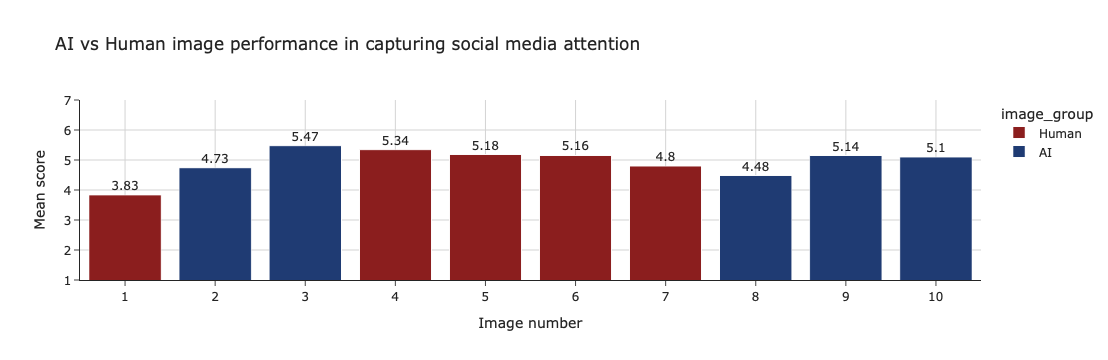

In [70]:
#filtering attention data, mapping ai vs human, and computing mean score per image: 
interest_summary = (
    ratings_long[ratings_long["item"] == "captures_attention"]
    .assign(image_group=lambda x: x["image_number"].map({
        1: "Human", 2: "AI", 3: "AI", 4: "Human", 5: "Human",
        6: "Human", 7: "Human", 8: "AI", 9: "AI", 10: "AI"
    }))
    .groupby(["image_number", "image_group"])["score"]
    .mean()
    .reset_index()
)

#identifying the image which performed best in capturing attention overall:
top_image = interest_summary.loc[interest_summary["score"].idxmax()]
print("Top performing image:\n", top_image)

#creating a bar chart to compare how each image performs in capturing attention:
fig = px.bar(
    interest_summary,
    x="image_number",
    y="score",
    color="image_group",
    title="AI vs Human image performance in capturing social media attention",
    text=interest_summary["score"].round(2),
    color_discrete_map={"AI": "#1f3b73", "Human": "#8b1e1e"}
)

fig.update_traces(textposition="outside")

#applying consistent styling for readability and clean presentation:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="Image number", dtick=1, showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(title="Mean score", range=[1, 7], dtick=1, showgrid=True, gridcolor="lightgrey")
)

fig.show()

#### 3.6 impact of ai familiarity on perception: 

Finally, the last part of this analysis examines whether familiarity with AI influences how respondents evaluate AI vs human created images. Subsection 3.6 therefore considers whether prior exposure to AI shapes evaluation patterns, moving beyond individual perception and demographic differences.

The results show that higher familiarity with AI is associated with a reduced gap in evaluations between AI generated and human created images. Rather than being driven purely by image characteristics, differences in perception appear to be shaped by respondents’ exposure to AI, with greater familiarity linked to lower scepticism and more aligned evaluations across both image types. Furthermore, a temporal dimension emerges from this pattern, indicating that current perceptual differences are not fixed but likely to evolve as familiarity increases. In relation to the main research question, this subsection reinforces a key theme across the analysis: that the extent to which generative AI can match or exceed human created marketing content depends not only on technical capability, but also on how such content is perceived by evolving audiences.

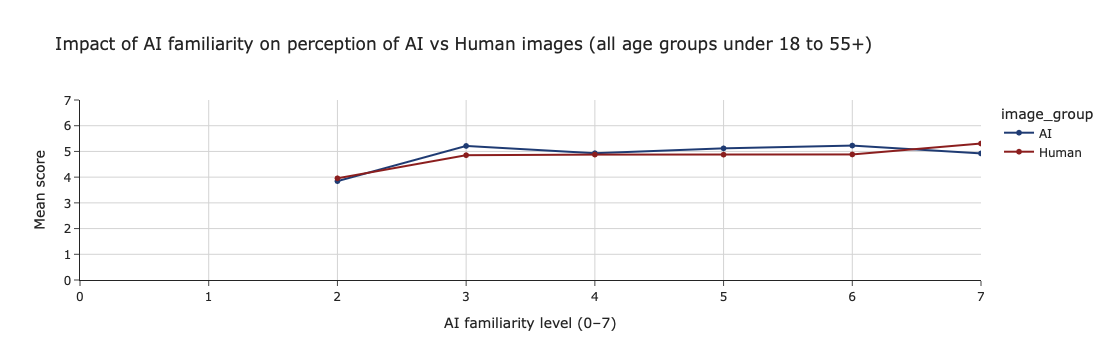

In [71]:
#converting familiarity variable to numeric to ensure consistent grouping and avoid errors:
ratings_long["Familiarity with AI images tools"] = pd.to_numeric(ratings_long["Familiarity with AI images tools"], errors="coerce")

#grouping data to calculate mean perception scores for ai vs human images across familiarity levels:
familiarity_analysis = filtered.dropna(subset=["Familiarity with AI images tools"]).groupby(["Familiarity with AI images tools", "image_group"])["score"].mean().reset_index()

#creating line chart to visualise how perception changes with increasing familiarity:
fig = px.line(
    familiarity_analysis,
    x="Familiarity with AI images tools",
    y="score",
    color="image_group",
    markers=True,
    title="Impact of AI familiarity on perception of AI vs Human images (all age groups under 18 to 55+)",
    color_discrete_map={"AI": "#1f3b73", "Human": "#8b1e1e"}
)

#applying consistent styling with full axis ranges and evenly spaced ticks for clarity:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="AI familiarity level (0–7)", range=[0, 7], dtick=1, showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(title="Mean score", range=[0, 7], dtick=1, showgrid=True, gridcolor="lightgrey")
)

fig.show()

In [72]:
perception_summary = (
    filtered
    .groupby("image_group")["score"]
    .mean()
    .reset_index()
)

print("Perception (mean scores):")
print(perception_summary)

Perception (mean scores):
  image_group    score
0          AI  5.02490
1       Human  4.91004


In [74]:
#creating table to summarise mean perception scores by familiarity level and image type:
familiarity_table = (
    familiarity_analysis
    .pivot(index="Familiarity with AI images tools", columns="image_group", values="score")
    .reset_index()
)

#renaming columns for clarity:
familiarity_table.columns.name = None
familiarity_table = familiarity_table.rename(columns={
    "Familiarity with AI images tools": "AI familiarity level",
    "AI": "AI",
    "Human": "Human"
})

print(familiarity_table.round(2))

   AI familiarity level    AI  Human
0                     2  3.84   3.96
1                     3  5.21   4.85
2                     4  4.93   4.88
3                     5  5.12   4.87
4                     6  5.23   4.88
5                     7  4.92   5.31


### 4. Supplementary exploratory analysis:

While the main analysis focuses on directly addressing the research questions through structured comparisons between AI and human generated images, additional exploratory visualisations were conducted to examine broader patterns within the dataset.

These analyses are primarily used as internal diagnostic tools to identify trends, variation, and any potential outliers across images, evaluation dimensions, and demographic groups. They support interpretation of the main findings but are not central to answering the research questions and are therefore not included in the final presentation.

#### 4.1 Heatmap of image performance across evaluation dimensions:

The heatmap below provides a consolidated overview of how each image performs across all evaluation dimensions simultaneously. By visualising the full pattern of scores in a single view, it allows for easier identification of consistent strengths, weaker attributes, and variation across images. Moreover, the purpose of this analysis is to support interpretation of the main findings by highlighting whether certain dimensions systematically underperform relative to others, and whether performance patterns are consistent across both AI generated and human created images.

In [65]:
#summarising average ratings across all images and evaluation dimensions to see overall performance patterns:
heatmap_data = ratings_long.pivot_table(index="image_number", columns="item_label", values="score", aggfunc="mean")

#sorting image numbers to ensure the heatmap follows a clear top-to-bottom order:
heatmap_data = heatmap_data.sort_index()

#creating heatmap to visually compare how each image performs across all evaluation dimensions:
fig = px.imshow(
    heatmap_data,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="YlGnBu",
    zmin=1, zmax=7,
    title="Mean rating by image and evaluation dimension"
)

#adjusting axes and colour scale so values are easy to interpret across the full likert range:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="Evaluation dimension"),
    yaxis=dict(
        title="Image number",
        tickmode="linear",
        dtick=1
    ),
    coloraxis_colorbar=dict(
        title="Mean score",
        tickmode="linear",
        dtick=1
    )
)

fig.show()

#### 4.2 Ranking of evaluation dimensions by overall score:

Subsection 4.2 focuses on average ratings which are compared across all individual evaluation dimensions included in the survey. While the main analysis groups these dimensions under broader categories such as quality, realism, and aesthetics, this view separates them to provide a more detailed and attribute level perspective.

Examining the dimensions individually helps identify which specific aspects of visual performance drive stronger or weaker evaluations, allowing for a more precise understanding of where perceptions are concentrated, and limitations associated with AI images. As such, the chart supports the interpretation of how different elements contribute to overall image performance.

In [66]:
#calculating average score for each evaluation dimension to identify strongest and weakest attributes:
avg_by_item = ratings_long.groupby("item_label")["score"].mean().reset_index().sort_values("score", ascending=False)

#creating horizontal bar chart to rank evaluation dimensions based on overall perception:
fig = px.bar(
    avg_by_item,
    x="score",
    y="item_label",
    text=avg_by_item["score"].round(2),
    title="Average rating by evaluation dimension",
    color_discrete_sequence=["#1f3b73"]
)

#adding value labels:
fig.update_traces(textposition="outside")

#styling:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="Mean score", range=[1,7], showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(title="", showgrid=False),
    showlegend=False
)

fig.show()

#### 4.3 Perception differences across gender:

Given that the main analysis explored variation across age groups, gender was considered as an additional demographic factor to assess whether similar differences in perception emerge. It provided a broader view of whether evaluation patterns are consistent across respondent characteristics.

However, the results show minimal variation across gender, with both image groups receiving broadly similar evaluations across all genders. While male respondents show slightly higher scores overall, these differences are marginal and do not indicate a meaningful shift in perception or a stronger ability to distinguish between AI and human content.

As a result, gender does not appear to be a significant factor influencing perception in this study, and does not materially contribute to answering the main research question. Instead, the findings reinforce that the key differences in evaluation are more strongly explained by image characteristics and familiarity with AI, rather than demographic variation across gender.

In [67]:
#filtering full dataset to analyse overall perception differences across gender:
gender_data = filtered.copy()

#cleaning gender labels to ensure consistency across responses:
gender_data["Gender"] = gender_data["Gender"].astype(str).str.strip()

#calculating mean perception scores by gender and image type to compare ai vs human:
gender_summary = gender_data.dropna(subset=["Gender"]).groupby(["Gender", "image_group"])["score"].mean().reset_index()

import plotly.express as px

#creating grouped bar chart to compare ai vs human perception across gender:
fig = px.bar(
    gender_summary,
    x="Gender",
    y="score",
    color="image_group",
    barmode="group",
    text=gender_summary["score"].round(2),
    title="Perception of AI vs Human images across gender",
    color_discrete_map={"AI": "#1f3b73", "Human": "#8b1e1e"}
)

#adding value labels above bars for clarity:
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

#applying consistent styling to match other visuals:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="Gender", showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(title="Mean score", range=[1, 7], dtick=1, showgrid=True, gridcolor="lightgrey")
)

fig.show()

#### 4.4 Outlier detection: 

A final analysis was conducted to detect outliers using the IQR method, assessing whether any extreme or irregular responses were present within the dataset, both overall and across individual evaluation dimensions. 

The results indicate that no significant outliers exist, suggesting that the distribution of responses is stable and not influenced by anomalous observations. In addition, visual inspection through the box plot confirms this pattern, with consistent interquartile ranges and no abnormal dispersion across evaluation dimensions. Such consistency indicates that variability in the data reflects genuine differences in perception rather than statistical noise or distortion.

Therefore, given the absence of irregular patterns, this analysis does not extend the core findings. Instead, it serves as a final validation of the dataset’s integrity, supporting the reliability of the results presented throughout the study and confirming that the conclusions drawn are based on consistent and well distributed responses.

Total outliers (overall dataset): 0
Outliers by evaluation dimension: 0


/var/folders/mj/_4pqmhhj2ssf5gdybtglbdlc0000gn/T/ipykernel_31733/4192744096.py:34: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



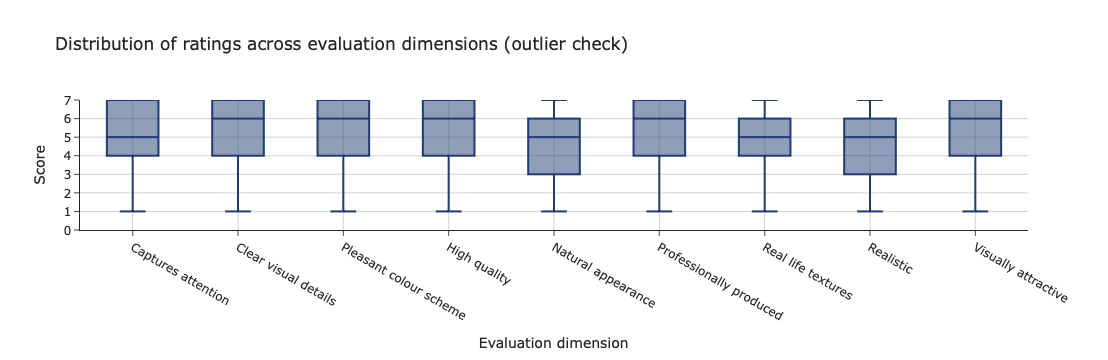

In [88]:
#checking for outliers in the dataset using the IQR method to identify any unusual or extreme rating patterns:

#copying the dataset to avoid modifying the original:
outlier_data = ratings_long.copy()

#calculating quartiles and interquartile range to define normal score distribution:
Q1 = outlier_data["score"].quantile(0.25)
Q3 = outlier_data["score"].quantile(0.75)
IQR = Q3 - Q1

#setting lower and upper bounds beyond which values are considered outliers:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#filtering observations that fall outside the expected range:
outliers_overall = outlier_data[
    (outlier_data["score"] < lower_bound) |
    (outlier_data["score"] > upper_bound)
]

print("Total outliers (overall dataset):", len(outliers_overall))

#extending the same approach to identify outliers within each evaluation dimension:
def detect_outliers(group):
    Q1 = group["score"].quantile(0.25)
    Q3 = group["score"].quantile(0.75)
    IQR = Q3 - Q1
    return group[
        (group["score"] < Q1 - 1.5 * IQR) |
        (group["score"] > Q3 + 1.5 * IQR)
    ]

#grouping by evaluation dimension to detect whether any specific attribute shows irregular responses:
outliers_by_item = ratings_long.groupby("item_label", group_keys=False).apply(detect_outliers)

print("Outliers by evaluation dimension:", len(outliers_by_item))

#visualising the distribution of ratings across dimensions to validate the absence or presence of outliers:
fig = px.box(
    ratings_long,
    x="item_label",
    y="score",
    points="outliers",
    title="Distribution of ratings across evaluation dimensions (outlier check)",
    color_discrete_sequence=["#1f3b73"]
)

#applying consistent styling to match other visuals and ensure clarity:
fig.update_layout(
    template="simple_white",
    xaxis=dict(title="Evaluation dimension", showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(title="Score", range=[0, 7], dtick=1, showgrid=True, gridcolor="lightgrey")
)

fig.show()